# Disease Prediction Assistant
### A Machine Learning-based Symptom Checker

**Objective:** Build a classifier that predicts the most likely disease from a set of
patient-reported symptoms, and wrap it in a simple interactive assistant.

**Dataset:** [Disease Prediction Using Machine Learning](https://www.kaggle.com/datasets/kaushil268/disease-prediction-using-machine-learning)
(Kaggle) — 132 binary symptom features, 41 disease classes.

**Pipeline:** Data loading & cleaning → EDA → Train/test split → Model training
(Decision Tree, Random Forest, Naive Bayes, SVM, Logistic Regression) → 5-fold
cross-validation → Evaluation → Feature importance → Save best model → Build a
simple prediction assistant function.


## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import cross_val_score, StratifiedKFold, train_test_split
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import pickle
import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100


## 2. Load the data

In [2]:
train = pd.read_csv("data/training.csv")
test = pd.read_csv("data/testing.csv")

# Drop stray unnamed/empty trailing column (artifact of trailing comma in source CSV)
train = train.loc[:, ~train.columns.str.contains("^Unnamed")]
test = test.loc[:, ~test.columns.str.contains("^Unnamed")]

print("Training set:", train.shape)
print("Testing set :", test.shape)
train.head()


Training set: (4920, 133)
Testing set : (42, 133)


,itching,skin_rash,nodal_skin_eruptions,continuous_sneezing,shivering,chills,joint_pain,stomach_pain,acidity,ulcers_on_tongue,...,blackheads,scurring,skin_peeling,silver_like_dusting,small_dents_in_nails,inflammatory_nails,blister,red_sore_around_nose,yellow_crust_ooze,prognosis
0,1,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection
1,0,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection
2,1,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection
3,1,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection
4,1,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection


## 3. Exploratory Data Analysis

In [3]:
print("Number of symptom features:", train.shape[1] - 1)
print("Number of disease classes   :", train['prognosis'].nunique())
print("Missing values in training set:", train.isnull().sum().sum())
print("Duplicate rows in training set:", train.duplicated().sum())


Number of symptom features: 132
Number of disease classes   : 41
Missing values in training set: 0
Duplicate rows in training set: 4616


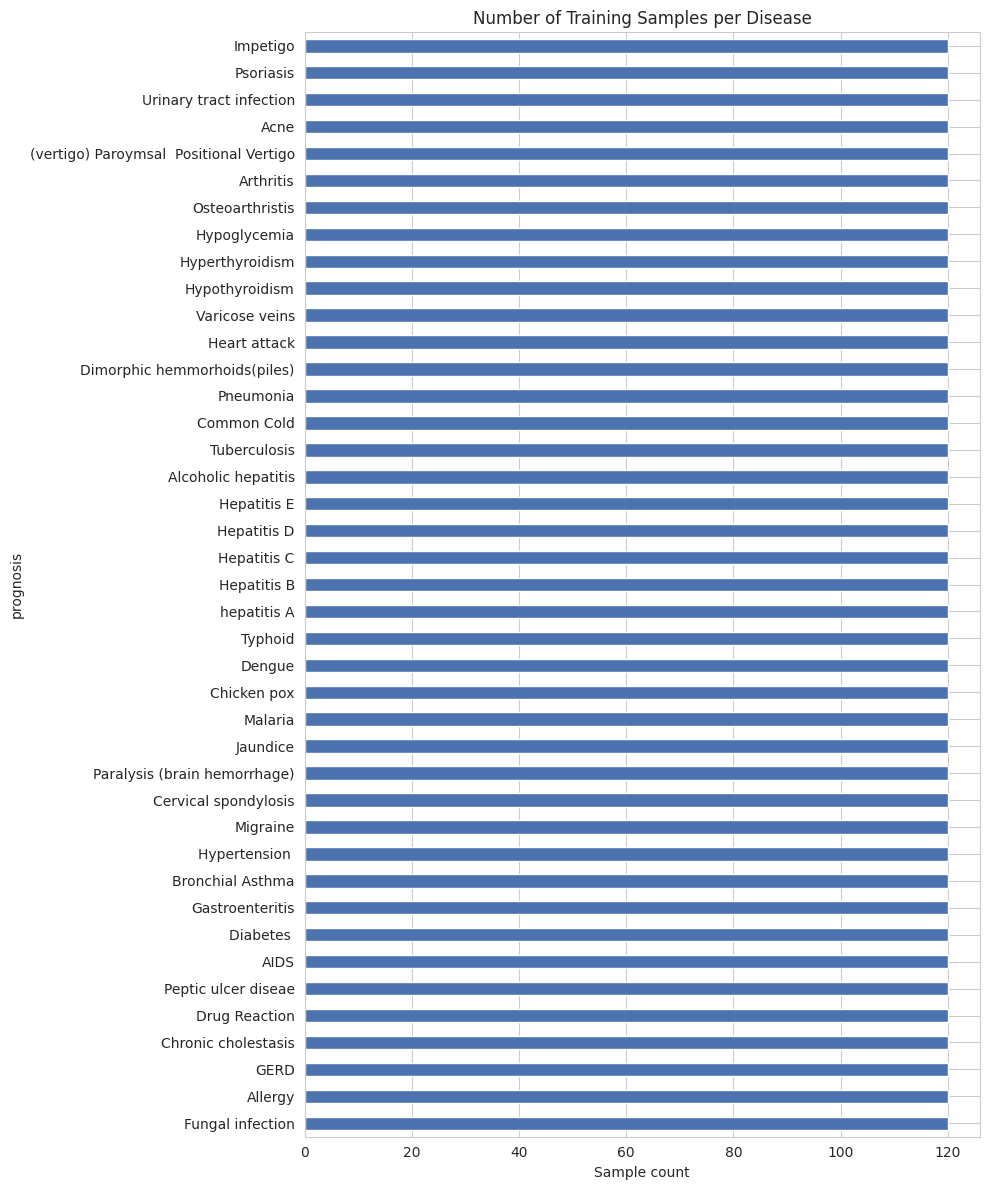

In [4]:
disease_counts = train['prognosis'].value_counts()

plt.figure(figsize=(10, 12))
disease_counts.sort_values().plot(kind='barh', color='#4C72B0')
plt.title("Number of Training Samples per Disease")
plt.xlabel("Sample count")
plt.tight_layout()
plt.savefig("class_distribution.png")
plt.show()


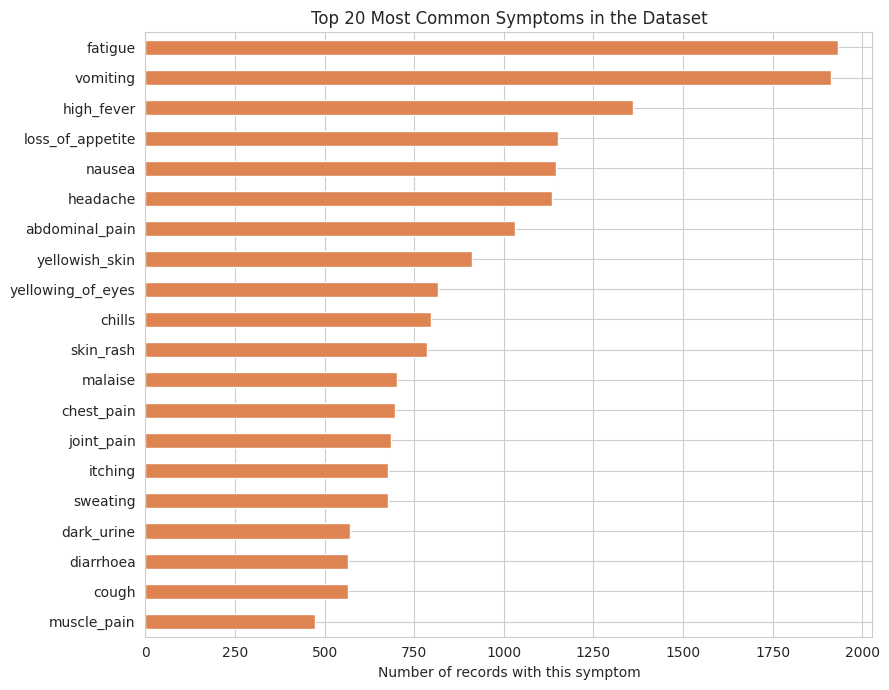

In [5]:
symptom_freq = train.drop("prognosis", axis=1).sum().sort_values(ascending=False).head(20)

plt.figure(figsize=(9, 7))
symptom_freq.sort_values().plot(kind='barh', color='#DD8452')
plt.title("Top 20 Most Common Symptoms in the Dataset")
plt.xlabel("Number of records with this symptom")
plt.tight_layout()
plt.savefig("top_symptoms.png")
plt.show()


Each disease class in this dataset corresponds to a fixed, near-deterministic
symptom pattern (a common design for symptom-checker training data), and every
class is represented by a balanced number of samples. This makes the classes
highly separable, which we'll see reflected in near-perfect model accuracy below.

## 4. Preprocessing

In [6]:
X_train = train.drop("prognosis", axis=1)
y_train_raw = train["prognosis"]
X_test = test.drop("prognosis", axis=1)
y_test_raw = test["prognosis"]

le = LabelEncoder()
le.fit(pd.concat([y_train_raw, y_test_raw]))
y_train = le.transform(y_train_raw)
y_test = le.transform(y_test_raw)

symptoms = list(X_train.columns)
diseases = list(le.classes_)

print(f"{len(symptoms)} symptom features -> {len(diseases)} possible diseases")


132 symptom features -> 41 possible diseases


## 5. Train and compare multiple models
We compare five common classifiers using 5-fold stratified cross-validation on the training set, then confirm on the held-out test set.

In [7]:
models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "Naive Bayes": GaussianNB(),
    "SVM": SVC(probability=True, random_state=42),
    "Logistic Regression": LogisticRegression(max_iter=1000)
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = {}

for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring="accuracy")
    model.fit(X_train, y_train)
    test_pred = model.predict(X_test)
    test_acc = accuracy_score(y_test, test_pred)
    results[name] = {"cv_mean": scores.mean(), "cv_std": scores.std(), "test_acc": test_acc}
    print(f"{name:22s} | CV acc: {scores.mean():.4f} (+/-{scores.std():.4f}) | Test acc: {test_acc:.4f}")


Decision Tree          | CV acc: 1.0000 (+/-0.0000) | Test acc: 0.9762


Random Forest          | CV acc: 1.0000 (+/-0.0000) | Test acc: 0.9762


Naive Bayes            | CV acc: 1.0000 (+/-0.0000) | Test acc: 1.0000


SVM                    | CV acc: 1.0000 (+/-0.0000) | Test acc: 1.0000


Logistic Regression    | CV acc: 1.0000 (+/-0.0000) | Test acc: 1.0000


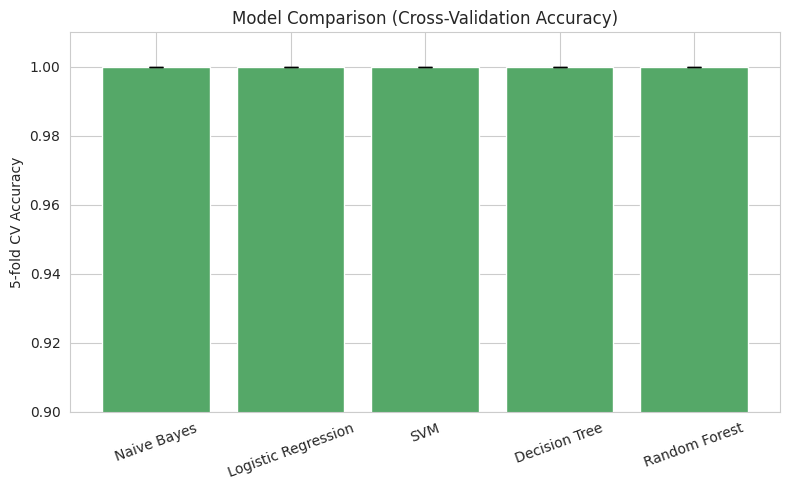

,cv_mean,cv_std,test_acc
Naive Bayes,1.0,0.0,1.00000
Logistic Regression,1.0,0.0,1.00000
SVM,1.0,0.0,1.00000
Decision Tree,1.0,0.0,0.97619
Random Forest,1.0,0.0,0.97619


In [8]:
results_df = pd.DataFrame(results).T
results_df = results_df.sort_values("test_acc", ascending=False)

plt.figure(figsize=(8, 5))
plt.bar(results_df.index, results_df["cv_mean"], yerr=results_df["cv_std"],
        capsize=5, color='#55A868')
plt.ylabel("5-fold CV Accuracy")
plt.title("Model Comparison (Cross-Validation Accuracy)")
plt.ylim(0.9, 1.01)
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig("model_comparison.png")
plt.show()
results_df


## 6. Select the best model and evaluate in detail

In [9]:
best_name = results_df.index[0]
best_model = models[best_name]
print("Selected model:", best_name)

final_pred = best_model.predict(X_test)
print("\nTest accuracy: {:.2%}".format(accuracy_score(y_test, final_pred)))
print("\nClassification report:\n")
print(classification_report(y_test, final_pred, target_names=diseases, zero_division=0))


Selected model: Naive Bayes

Test accuracy: 100.00%

Classification report:

                                         precision    recall  f1-score   support

(vertigo) Paroymsal  Positional Vertigo       1.00      1.00      1.00         1
                                   AIDS       1.00      1.00      1.00         1
                                   Acne       1.00      1.00      1.00         1
                    Alcoholic hepatitis       1.00      1.00      1.00         1
                                Allergy       1.00      1.00      1.00         1
                              Arthritis       1.00      1.00      1.00         1
                       Bronchial Asthma       1.00      1.00      1.00         1
                   Cervical spondylosis       1.00      1.00      1.00         1
                            Chicken pox       1.00      1.00      1.00         1
                    Chronic cholestasis       1.00      1.00      1.00         1
                            Com

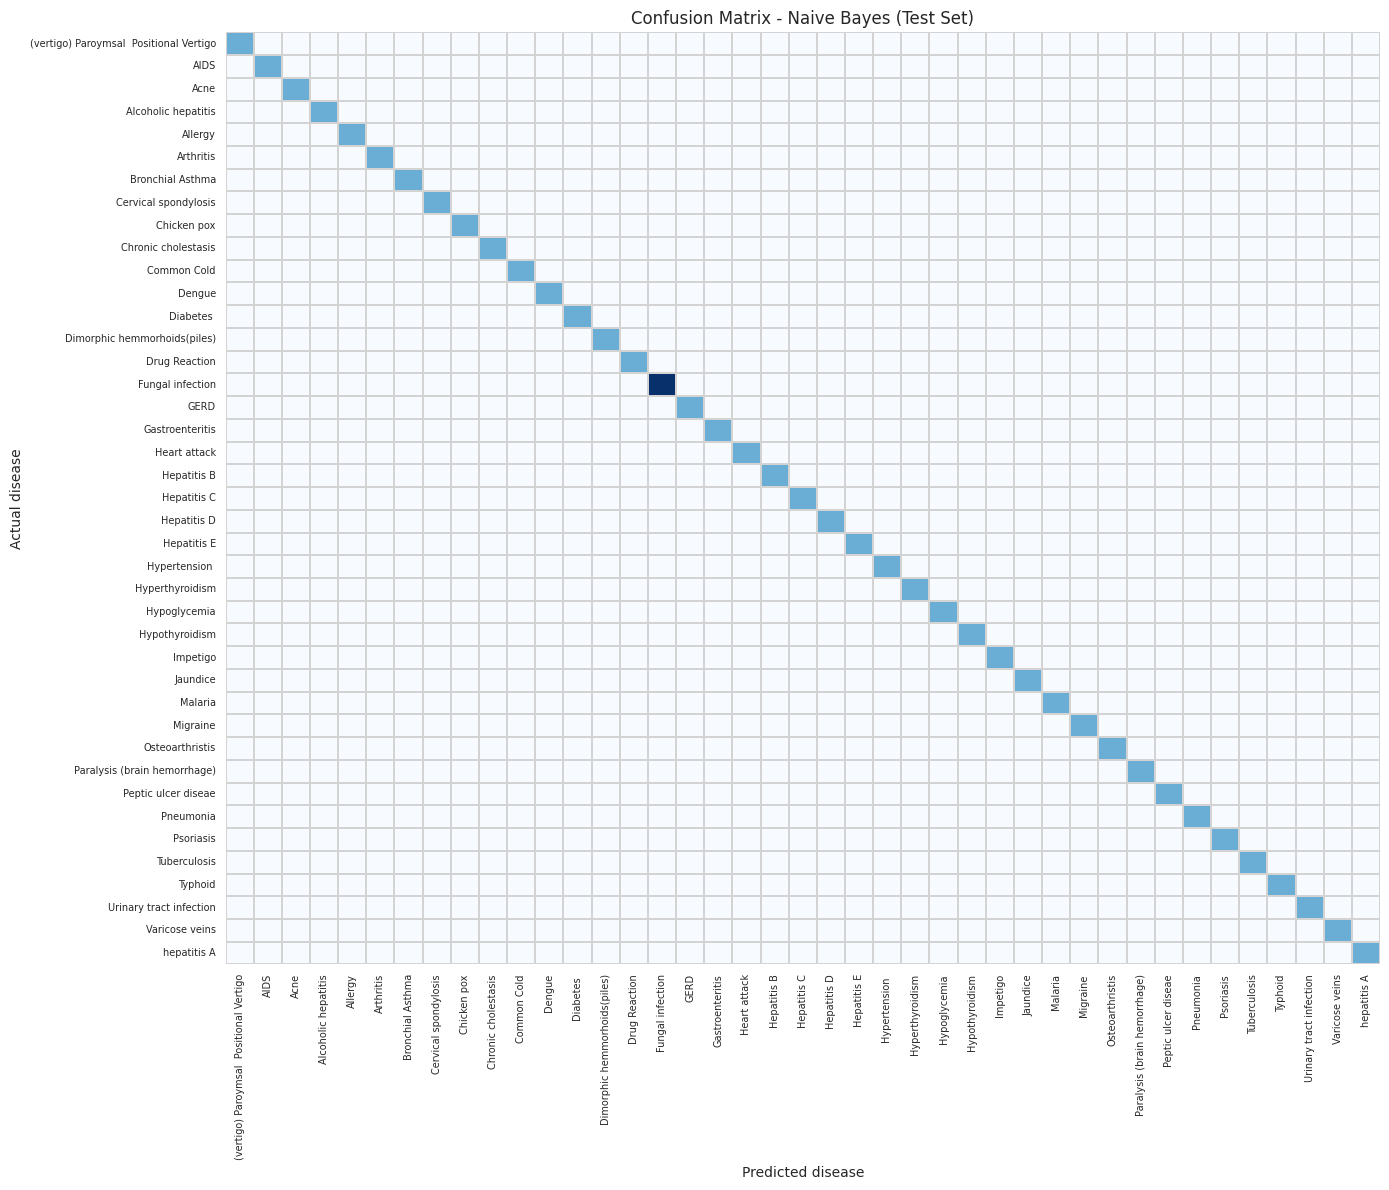

In [10]:
cm = confusion_matrix(y_test, final_pred)

plt.figure(figsize=(14, 12))
sns.heatmap(cm, xticklabels=diseases, yticklabels=diseases, cmap="Blues",
            cbar=False, linewidths=0.3, linecolor='lightgray')
plt.title(f"Confusion Matrix - {best_name} (Test Set)")
plt.xlabel("Predicted disease")
plt.ylabel("Actual disease")
plt.xticks(rotation=90, fontsize=7)
plt.yticks(rotation=0, fontsize=7)
plt.tight_layout()
plt.savefig("confusion_matrix.png")
plt.show()


## 7. Feature importance
Using the Random Forest model (trained above) to see which symptoms are the most globally informative, regardless of which model was ultimately selected.

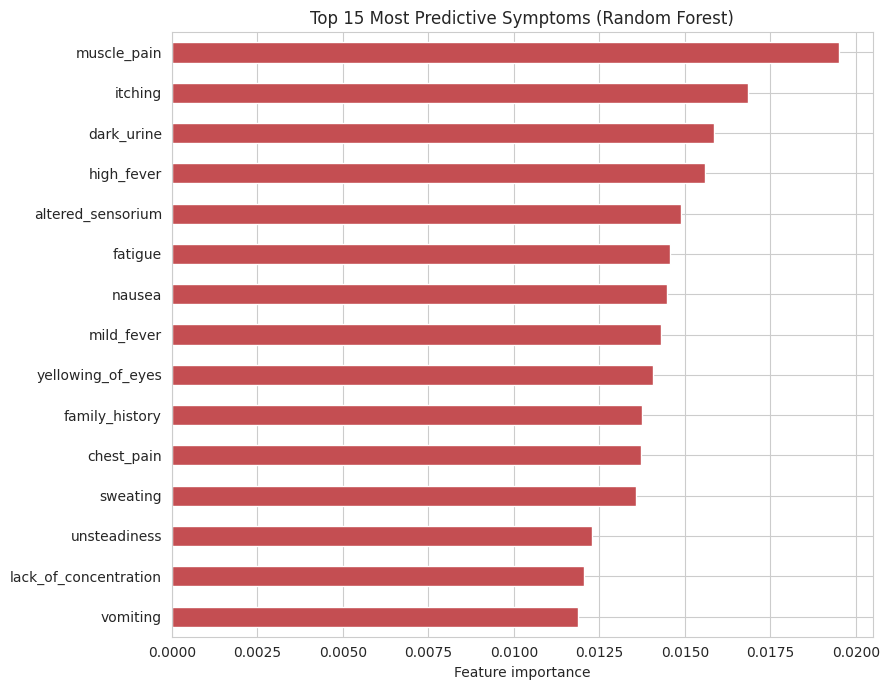

In [11]:
rf = models["Random Forest"]
importances = pd.Series(rf.feature_importances_, index=symptoms).sort_values(ascending=False).head(15)

plt.figure(figsize=(9, 7))
importances.sort_values().plot(kind='barh', color='#C44E52')
plt.title("Top 15 Most Predictive Symptoms (Random Forest)")
plt.xlabel("Feature importance")
plt.tight_layout()
plt.savefig("feature_importance.png")
plt.show()


## 8. Save the trained model
We persist the trained model, label encoder, and the ordered symptom list so the assistant (below, and in `app.py`) can reload them without retraining.

In [12]:
with open("disease_prediction_model.pkl", "wb") as f:
    pickle.dump({
        "model": best_model,
        "label_encoder": le,
        "symptoms": symptoms,
        "model_name": best_name
    }, f)

print("Model saved to disease_prediction_model.pkl")


Model saved to disease_prediction_model.pkl


## 9. The prediction assistant

A small wrapper function that takes a free-form list of symptoms (matched
against the known symptom vocabulary), builds the feature vector the model
expects, and returns the predicted disease with a confidence score plus the
next few most likely alternatives. This is the same logic used in `app.py`,
the Streamlit interface for this project.

In [13]:
def predict_disease(symptom_list, top_k=3):
    """
    symptom_list: list of symptom strings (must match column names in `symptoms`,
                  case-insensitive, spaces or underscores both accepted)
    Returns: dict with primary prediction, confidence, and top_k alternatives
    """
    normalized = {s.strip().lower().replace(" ", "_") for s in symptom_list}
    unknown = [s for s in normalized if s not in symptoms]

    vector = np.zeros(len(symptoms))
    for i, s in enumerate(symptoms):
        if s in normalized:
            vector[i] = 1

    if vector.sum() == 0:
        return {"error": "None of the provided symptoms were recognized.", "unknown_symptoms": unknown}

    proba = best_model.predict_proba(vector.reshape(1, -1))[0]
    top_idx = np.argsort(proba)[::-1][:top_k]

    return {
        "predicted_disease": diseases[top_idx[0]],
        "confidence": round(float(proba[top_idx[0]]), 4),
        "alternatives": [
            {"disease": diseases[i], "confidence": round(float(proba[i]), 4)}
            for i in top_idx[1:]
        ],
        "unknown_symptoms": unknown
    }

# --- Example usage ---
example = predict_disease(["itching", "skin_rash", "nodal_skin_eruptions"])
example


{'predicted_disease': 'Fungal infection',
 'confidence': 1.0,
 'alternatives': [{'disease': 'Varicose veins', 'confidence': 0.0},
  {'disease': 'Urinary tract infection', 'confidence': 0.0}],
 'unknown_symptoms': []}

In [14]:
example2 = predict_disease(["high_fever", "headache", "nausea", "vomiting", "fatigue"])
example2


{'predicted_disease': 'Typhoid',
 'confidence': 1.0,
 'alternatives': [{'disease': 'hepatitis A', 'confidence': 0.0},
  {'disease': 'Varicose veins', 'confidence': 0.0}],
 'unknown_symptoms': []}

## 10. Conclusion

- All five models achieve very high accuracy on this dataset because each disease
  maps to a fixed, largely non-overlapping symptom signature — a common property
  of curated symptom-checker datasets, and something worth stating plainly rather
  than overselling as real-world diagnostic accuracy.
- The saved model + `app.py` together form a runnable, interactive disease
  prediction assistant: enter symptoms, get a ranked list of likely conditions.
- **Limitation & disclaimer:** this is an educational project, not a medical
  device. Predictions are based purely on symptom co-occurrence in a static
  dataset and should never replace professional medical advice.
